In [1]:
import anndata as ad
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
import gc
from pathlib import Path
import matplotlib.pyplot as plt

## Loading data and helper functions

In [2]:
mg_ad_path = '/data/scRNA/RNA/scRNA/Hammond/preprocessing/GSE121654_T_P100_LC_common_concat_zero_filter_MTremoved.h5ad'
mg_ad = sc.read_h5ad(mg_ad_path)
mg_ad

AnnData object with n_obs × n_vars = 27177 × 10570
    obs: 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [3]:
sc.pp.normalize_total(mg_ad, target_sum=1e4)
sc.pp.log1p(mg_ad)
sc.pp.scale(mg_ad, max_value=10)
sc.tl.pca(mg_ad)
sc.pp.neighbors(mg_ad)
sc.tl.umap(mg_ad)

/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Define the condition based on batch values
conditions = pd.cut(mg_ad.obs['batch'].astype(int), bins=[-1, 10, 13, 16], labels=['control', 'saline', 'LC'])

# Add the condition column to the .obs attribute of mg_ad
mg_ad.obs['condition'] = conditions

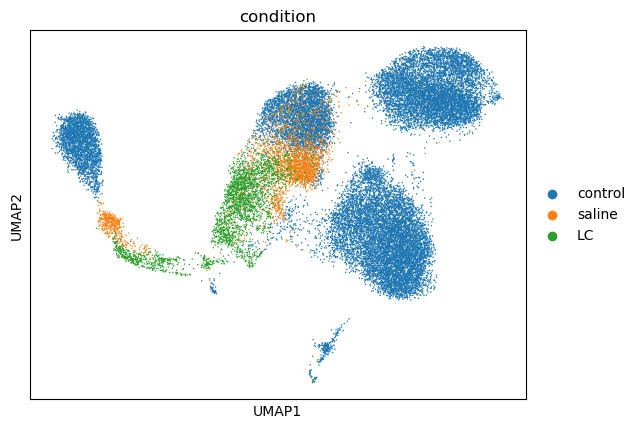

In [5]:
sc.pl.umap(mg_ad, color=['condition'])

In [6]:
# Integrate data
mg_intg = mg_ad.copy()
sc.external.pp.harmony_integrate(mg_intg, key='batch')
sc.pp.neighbors(mg_intg, use_rep='X_pca_harmony')
sc.tl.umap(mg_intg)

2025-03-14 19:08:16,959 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-03-14 19:08:21,470 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-03-14 19:08:21,576 - harmonypy - INFO - Iteration 1 of 10
2025-03-14 19:08:26,108 - harmonypy - INFO - Iteration 2 of 10
2025-03-14 19:08:32,053 - harmonypy - INFO - Converged after 2 iterations


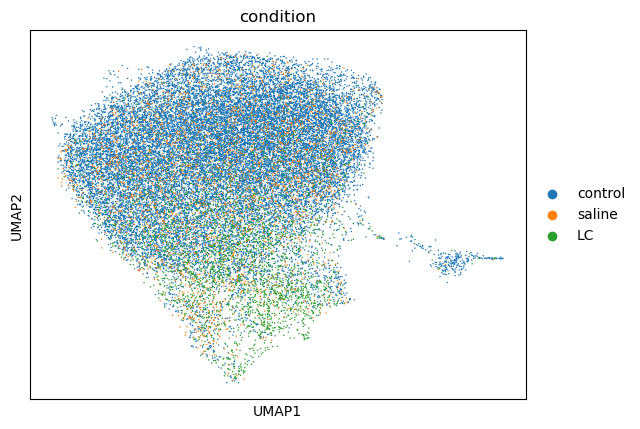

In [7]:
sc.pl.umap(mg_intg, color=['condition'])

In [26]:
# Making a dictionary of module dataframes
module_dfs = {}

# Initialize an empty dataframe to store the MEs
MEs_df = pd.DataFrame(index=mg_ad.obs_names)

**Control modules**

In [28]:
# Loading data for the condition
condition = "Control"

In [29]:
# Load modules dataframe
module_dfs[condition] = pd.read_csv(
    "/data/scRNA/RNA/scRNA/Hammond/preprocessing/hdWGCNA/GO/NoRP/hdWGCNA_HVG2K_normal_NoRP_modules.csv",
    index_col = "Unnamed: 0")
module_dfs[condition].head()

,gene_name,module,color,kME_NORM-NoRP-M1,kME_NORM-NoRP-M2,kME_grey,kME_NORM-NoRP-M3,kME_NORM-NoRP-M4
Cd74,Cd74,NORM-NoRP-M1,brown,0.150583,0.419821,0.018544,0.175201,-0.040476
Apoe,Apoe,NORM-NoRP-M1,brown,0.152592,0.300385,0.036027,0.236322,-0.015315
H2.Ab1,H2.Ab1,NORM-NoRP-M2,blue,0.103400,0.393140,0.000632,0.121813,-0.045858
H2.Aa,H2.Aa,NORM-NoRP-M1,brown,0.124929,0.394893,-0.008771,0.112483,-0.048529
H2.Eb1,H2.Eb1,NORM-NoRP-M1,brown,0.120687,0.390966,-0.000478,0.119566,-0.055707


In [30]:
# Rename the modules in the modules dataframe
module_dfs[condition]['module'] = module_dfs[condition]['module'].str.replace("NORM-NoRP", "MG-Control")

# Getting names of modules
modules = module_dfs[condition]["module"].unique().tolist()
modules.remove("grey")
modules

['MG-Control-M1', 'MG-Control-M2', 'MG-Control-M3', 'MG-Control-M4']

In [32]:
# Loop through each module and calculate the first principal component
for module_name in modules:
    if module_name == "grey":
        continue
    select_genes = module_dfs[condition][module_dfs[condition]["module"] == module_name].index
    common_genes = mg_ad.var_names.intersection(select_genes)
    adata_subset = mg_ad[:, common_genes].copy()
    
    # Perform PCA
    sc.tl.pca(adata_subset, n_comps=1, svd_solver="arpack")
    
    # Extract the first principal component values
    pc1_values = adata_subset.obsm['X_pca'][:, 0]
    
    # Add the first principal component values to the dataframe
    MEs_df[module_name] = pc1_values

# Display the combined dataframe
MEs_df.head()

,MG-Control-M1,MG-Control-M2,MG-Control-M3,MG-Control-M4
TTAGGACAGAGGGCTT-1-0,-1.169876,-2.166831,-3.204422,0.024398
GGCGACTTCCAAATGC-1-0,0.143037,-0.702048,0.371387,3.506355
TCATTACTCGTGGACC-1-0,0.110684,-1.778119,0.267249,5.559175
GCAAACTTCGGCGGTT-1-0,1.737980,14.839459,2.588130,-0.436394
GGAATAATCACAGGCC-1-0,0.703741,-0.975588,-0.009245,6.603214


**Saline modules**

In [33]:
# Loading data for the condition
condition = "Saline"

In [34]:
# Load modules dataframe
module_dfs[condition] = pd.read_csv(
    "/data/scRNA/RNA/scRNA/Hammond/preprocessing/hdWGCNA/GO/NoRP/hdWGCNA_HVG2K_saline_NoRP_modules.csv",
    index_col = "Unnamed: 0")
module_dfs[condition].head()

,gene_name,module,color,kME_SALINE-NoRP-M1,kME_grey,kME_SALINE-NoRP-M2,kME_SALINE-NoRP-M3
Apoe,Apoe,SALINE-NoRP-M1,blue,0.328732,0.441214,0.320913,0.270716
Ccl4,Ccl4,grey,grey,0.162866,0.414139,0.149515,0.129828
Ccl12,Ccl12,SALINE-NoRP-M1,blue,0.543086,0.105978,0.105050,0.050860
Ccl3,Ccl3,SALINE-NoRP-M1,blue,0.093986,0.320780,0.147746,0.129622
Lpl,Lpl,SALINE-NoRP-M1,blue,0.235353,0.472862,0.204790,0.199218


In [35]:
# Rename the modules in the modules dataframe
module_dfs[condition]['module'] = module_dfs[condition]['module'].str.replace("SALINE-NoRP", "MG-Saline")

# Getting names of modules
modules = module_dfs[condition]["module"].unique().tolist()
modules.remove("grey")
modules

['MG-Saline-M1', 'MG-Saline-M2', 'MG-Saline-M3']

In [36]:
# Loop through each module and calculate the first principal component
for module_name in modules:
    if module_name == "grey":
        continue
    select_genes = module_dfs[condition][module_dfs[condition]["module"] == module_name].index
    common_genes = mg_ad.var_names.intersection(select_genes)
    adata_subset = mg_ad[:, common_genes].copy()
    
    # Perform PCA
    sc.tl.pca(adata_subset, n_comps=1, svd_solver="arpack")
    
    # Extract the first principal component values
    pc1_values = adata_subset.obsm['X_pca'][:, 0]
    
    # Add the first principal component values to the dataframe
    MEs_df[module_name] = pc1_values

# Display the combined dataframe
MEs_df.head()

,MG-Control-M1,MG-Control-M2,MG-Control-M3,MG-Control-M4,MG-Saline-M1,MG-Saline-M2,MG-Saline-M3
TTAGGACAGAGGGCTT-1-0,-1.169876,-2.166831,-3.204422,0.024398,-2.669400,-2.410477,-2.216480
GGCGACTTCCAAATGC-1-0,0.143037,-0.702048,0.371387,3.506355,-0.542864,-0.317409,0.807178
TCATTACTCGTGGACC-1-0,0.110684,-1.778119,0.267249,5.559175,-1.504540,-0.321982,1.582667
GCAAACTTCGGCGGTT-1-0,1.737980,14.839459,2.588130,-0.436394,14.769748,0.027205,2.264306
GGAATAATCACAGGCC-1-0,0.703741,-0.975588,-0.009245,6.603214,-1.464263,-1.437867,1.478742


**ME: LC modules**

In [37]:
# Loading data for the condition
condition = "LC"

In [38]:
# Load modules dataframe
module_dfs[condition] = pd.read_csv(
    "/data/scRNA/RNA/scRNA/Hammond/preprocessing/hdWGCNA/GO/NoRP/hdWGCNA_HVG2K_injury_NoRP_modules.csv",
    index_col = "Unnamed: 0")
module_dfs[condition].head()

,gene_name,module,color,kME_INJURY-NORP-M1,kME_INJURY-NORP-M2,kME_grey,kME_INJURY-NORP-M3
Ccl4,Ccl4,INJURY-NORP-M1,turquoise,0.449157,0.202290,0.093461,-0.192942
Cxcl10,Cxcl10,INJURY-NORP-M1,turquoise,0.448920,0.072827,0.053286,-0.153673
Ccl5,Ccl5,INJURY-NORP-M1,turquoise,0.306227,0.095109,0.015581,-0.194044
Ccl3,Ccl3,INJURY-NORP-M1,turquoise,0.413146,0.229298,0.095060,-0.208930
Ccl12,Ccl12,INJURY-NORP-M1,turquoise,0.496430,0.123100,0.075157,-0.224386


In [40]:
# Rename the modules in the modules dataframe
module_dfs[condition]['module'] = module_dfs[condition]['module'].str.replace("INJURY-NORP", "MG-LC")

# Getting names of modules
modules = module_dfs[condition]["module"].unique().tolist()
modules.remove("grey")
modules

['MG-LC-M1', 'MG-LC-M2', 'MG-LC-M3']

In [41]:
# Loop through each module and calculate the first principal component
for module_name in modules:
    if module_name == "grey":
        continue
    select_genes = module_dfs[condition][module_dfs[condition]["module"] == module_name].index
    common_genes = mg_ad.var_names.intersection(select_genes)
    adata_subset = mg_ad[:, common_genes].copy()
    
    # Perform PCA
    sc.tl.pca(adata_subset, n_comps=1, svd_solver="arpack")
    
    # Extract the first principal component values
    pc1_values = adata_subset.obsm['X_pca'][:, 0]
    
    # Add the first principal component values to the dataframe
    MEs_df[module_name] = pc1_values

# Display the combined dataframe
MEs_df.head()

,MG-Control-M1,MG-Control-M2,MG-Control-M3,MG-Control-M4,MG-Saline-M1,MG-Saline-M2,MG-Saline-M3,MG-LC-M1,MG-LC-M2,MG-LC-M3
TTAGGACAGAGGGCTT-1-0,-1.169876,-2.166831,-3.204422,0.024398,-2.669400,-2.410477,-2.216480,-2.981376,-2.540927,-1.259964
GGCGACTTCCAAATGC-1-0,0.143037,-0.702048,0.371387,3.506355,-0.542864,-0.317409,0.807178,-0.036449,0.401611,1.831977
TCATTACTCGTGGACC-1-0,0.110684,-1.778119,0.267249,5.559175,-1.504540,-0.321982,1.582667,-0.991004,1.103993,2.621437
GCAAACTTCGGCGGTT-1-0,1.737980,14.839459,2.588130,-0.436394,14.769748,0.027205,2.264306,14.622179,2.246968,-0.728454
GGAATAATCACAGGCC-1-0,0.703741,-0.975588,-0.009245,6.603214,-1.464263,-1.437867,1.478742,0.161038,1.575939,1.221945


**Visualizing**

In [42]:
# Ensure the indices match
assert all(MEs_df.index == mg_ad.obs.index)

# Add the MEs_df to mg_ad.obs
mg_ad.obs = mg_ad.obs.join(MEs_df)

# Verify the new columns
mg_ad.obs.head()

,batch,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,condition,MG-Control-M1,MG-Control-M2,MG-Control-M3,MG-Control-M4,MG-Saline-M1,MG-Saline-M2,MG-Saline-M3,MG-LC-M1,MG-LC-M2,MG-LC-M3
TTAGGACAGAGGGCTT-1-0,0,1229,1229,1922.0,6.0,0.312175,control,-1.169876,-2.166831,-3.204422,0.024398,-2.669400,-2.410477,-2.216480,-2.981376,-2.540927,-1.259964
GGCGACTTCCAAATGC-1-0,0,2187,2187,4954.0,21.0,0.423900,control,0.143037,-0.702048,0.371387,3.506355,-0.542864,-0.317409,0.807178,-0.036449,0.401611,1.831977
TCATTACTCGTGGACC-1-0,0,2086,2086,5015.0,29.0,0.578265,control,0.110684,-1.778119,0.267249,5.559175,-1.504540,-0.321982,1.582667,-0.991004,1.103993,2.621437
GCAAACTTCGGCGGTT-1-0,0,1804,1804,4764.0,8.0,0.167926,control,1.737980,14.839459,2.588130,-0.436394,14.769748,0.027205,2.264306,14.622179,2.246968,-0.728454
GGAATAATCACAGGCC-1-0,0,2002,2002,4264.0,10.0,0.234522,control,0.703741,-0.975588,-0.009245,6.603214,-1.464263,-1.437867,1.478742,0.161038,1.575939,1.221945


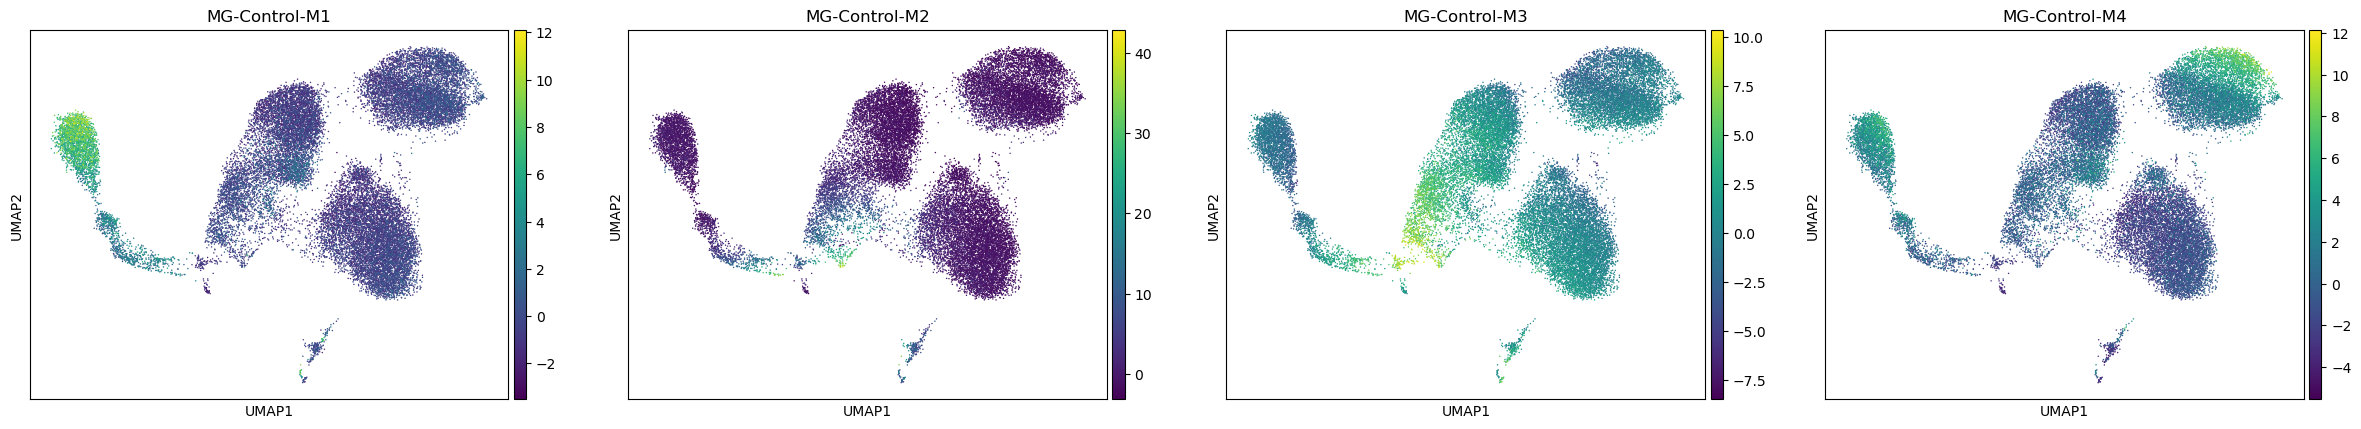

In [ ]:
# Control modules
modules = module_dfs["Control"]["module"].unique().tolist()
modules.remove("grey")
sc.pl.umap(mg_ad, color=modules)

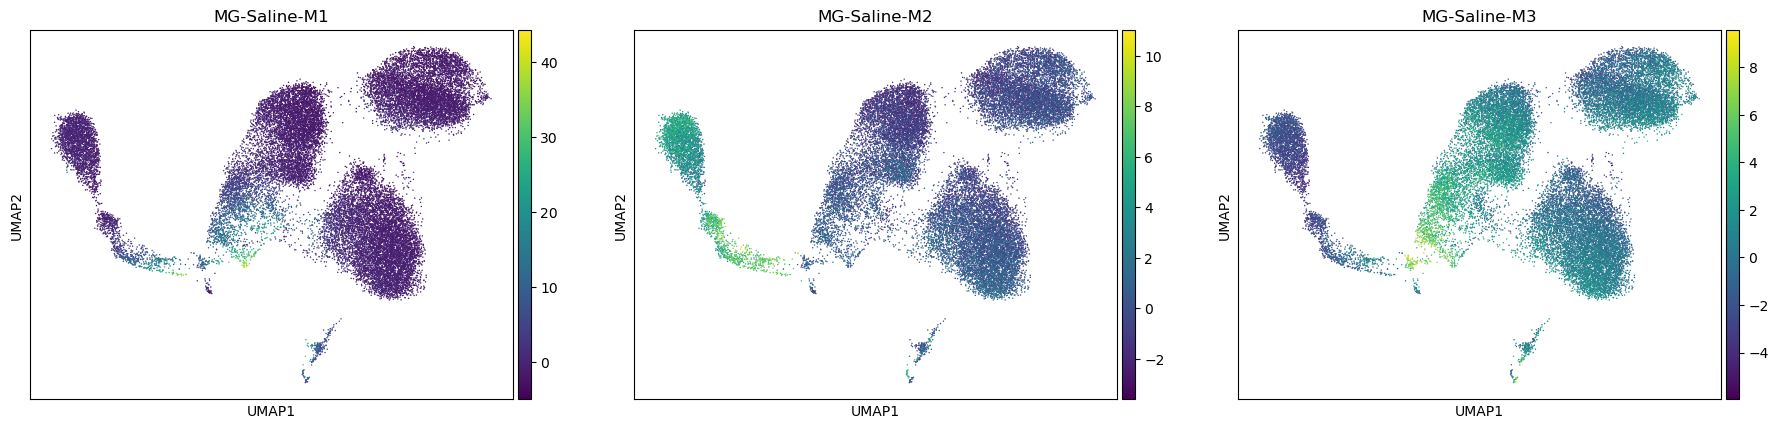

In [45]:
# Saline modules
modules = module_dfs["Saline"]["module"].unique().tolist()
modules.remove("grey")
sc.pl.umap(mg_ad, color=modules)

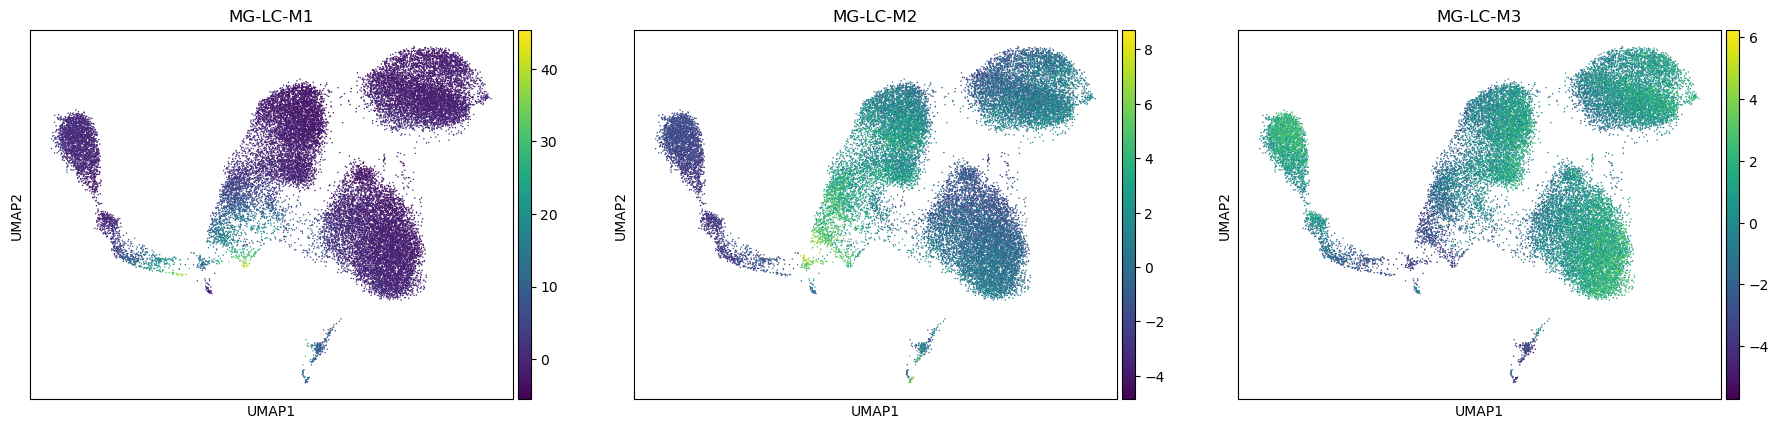

In [46]:
# LC modules
modules = module_dfs["LC"]["module"].unique().tolist()
modules.remove("grey")
sc.pl.umap(mg_ad, color=modules)

## Correlation of modules

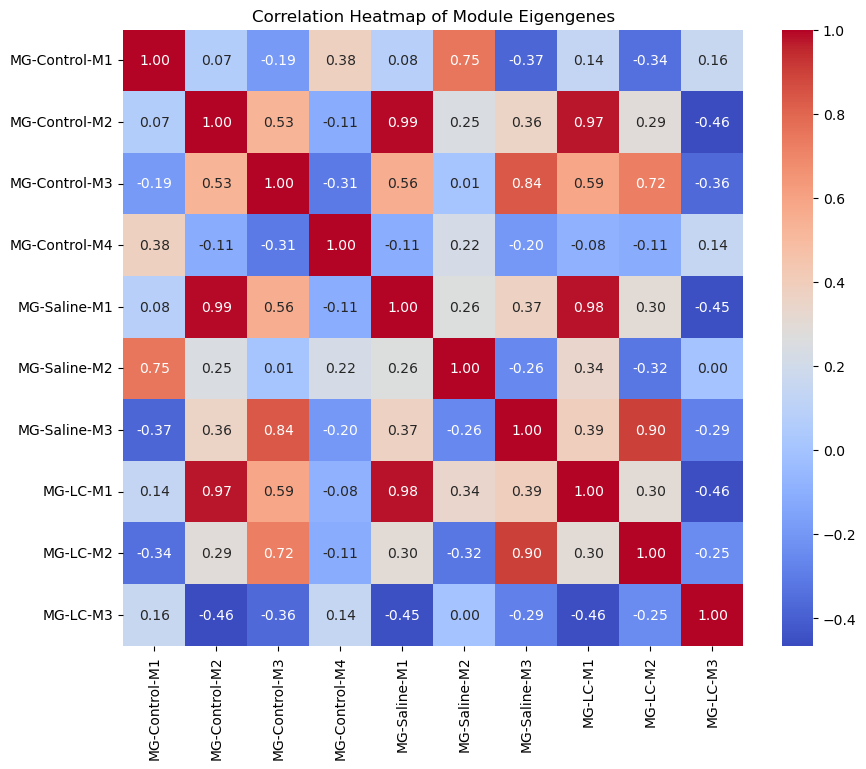

In [47]:
# Calculate the correlation matrix
corr_matrix = MEs_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Module Eigengenes')
plt.show()